#SVM : Support Vector Machine

1. Supervised ML
2. Classification & Regression
3. big data , complex data , linear , non-linear Data

# Some Defintions in SVM

1. Support Vectors
2. Margin : distance between hyperplane & support vectors
3. Hyperplane : Separate Data Points

#How SVM Work ?

1. Determine the support vectors
2. Get the margin
3. split the classes by hyperplane

## we Should make the margin as large as possible  - not small


## SVM’s goal is:

Find the hyperplane that maximizes the margin while still correctly classifying the data.

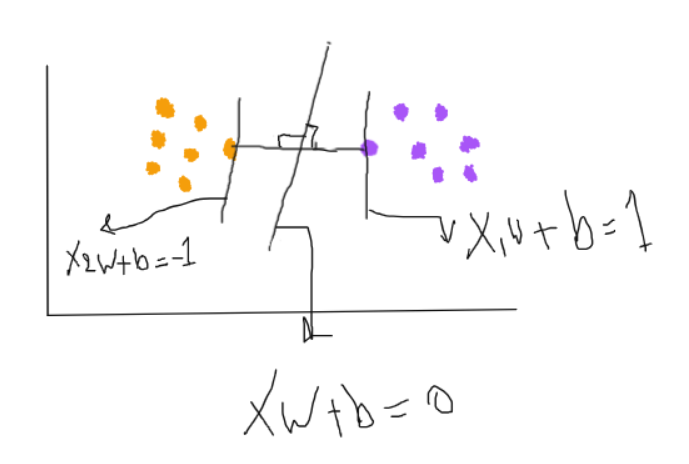

## how to calculate the margin ?
1. subtract L1 , L2
2. (X1W+b) - (X2W+b) = (1)-(-1)
    
    X1W-X2W=2

    W(X1-X2)=2

    Divide by |W|

    Margin=2/|W|

    

### Optimization :
minimize (J)


maximize the margin



#Shape of the data ?

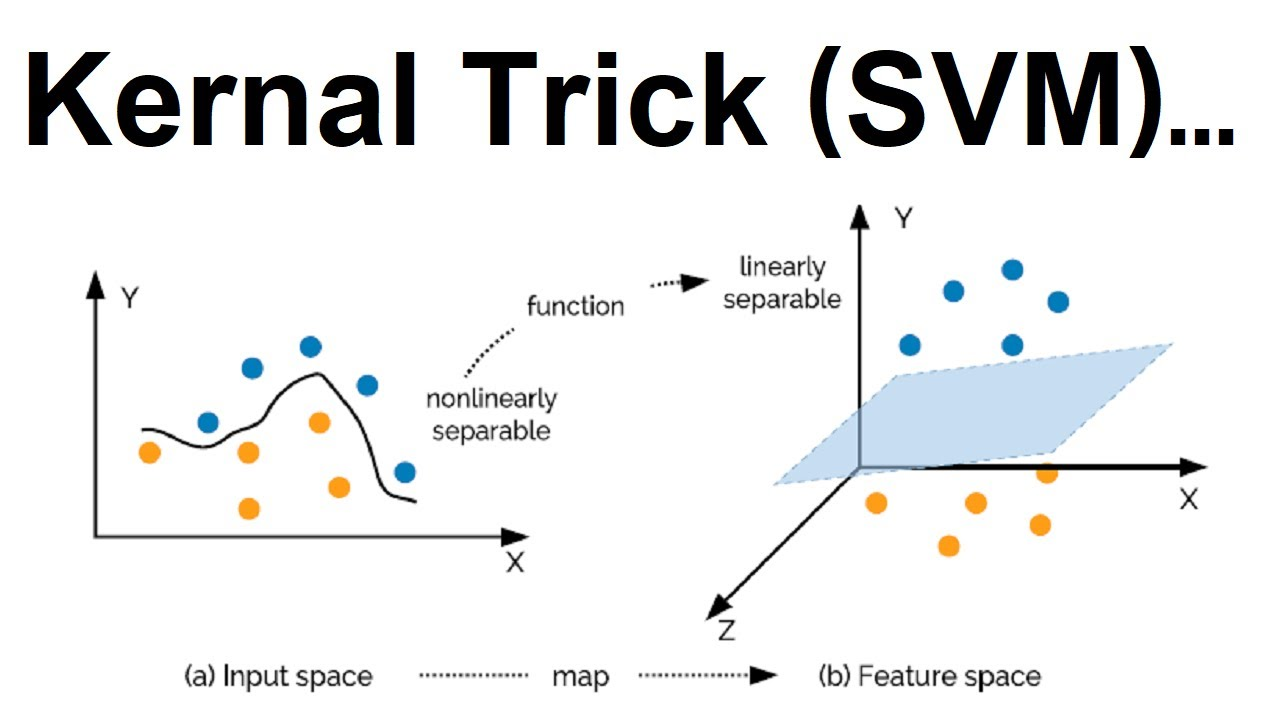

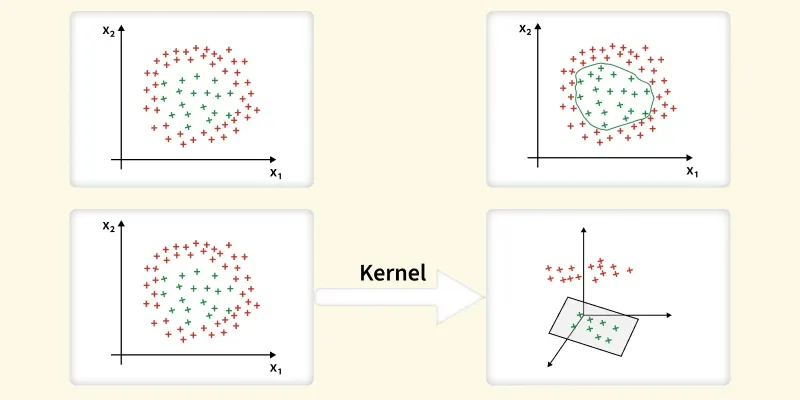

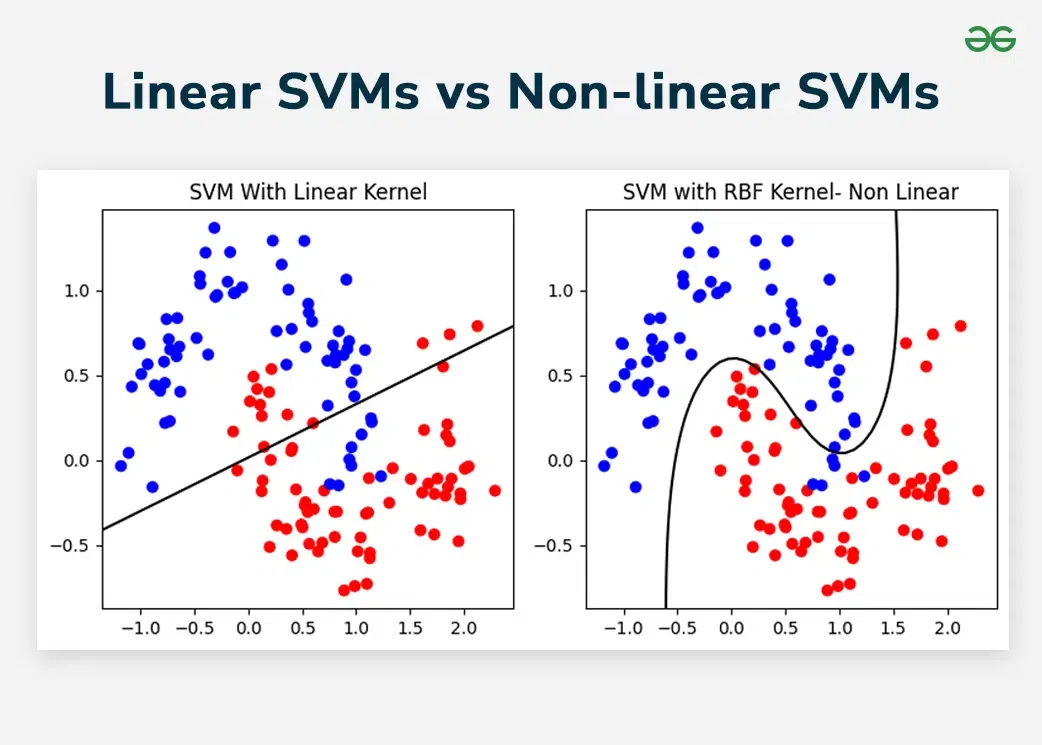

#Types of Kernel SVM

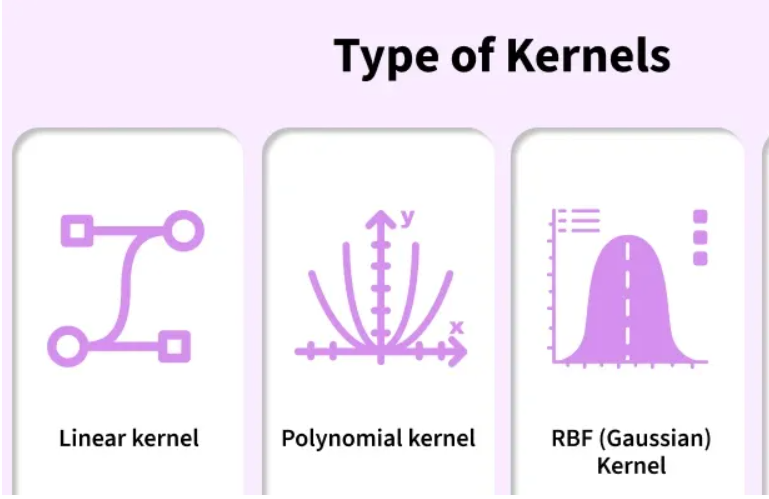

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC # svm => SVC , SVR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


import pandas as pd




In [5]:
df=pd.read_csv("/content/wine_dataset.csv")

In [6]:
df.head(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0


#split the data X , Y

In [7]:
x=df.drop('target', axis=1)
y=df['target']

In [8]:
x

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [9]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
173,2
174,2
175,2
176,2


In [10]:
x.shape

(178, 13)

In [11]:
y.shape

(178,)

#split Train , test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=42)

In [13]:
# Feature Scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Build The model

Accuracy: 0.9777777777777777


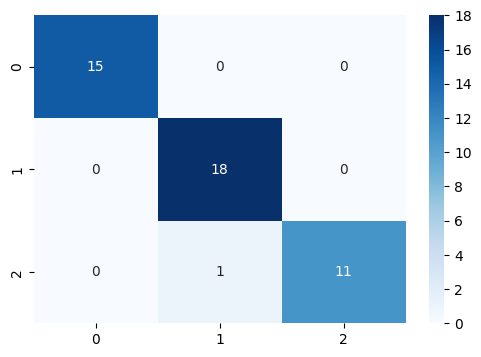

In [16]:
svm_model=SVC(C=1.0 , kernel='rbf',gamma='auto')


#Train teh model
svm_model.fit(X_train_scaled, y_train)

#Predict
y_pred = svm_model.predict(X_test_scaled)


# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues")
plt.show()



# Difference between parameters and hyperparameters
🔹 1️⃣ Parameters
### Definition:

Parameters are learned from the data during training.

They define the internal structure of the model.

The model adjusts them automatically to minimize the loss function.

Linear Regression => Slope w and intercept b

🔹 2️⃣ Hyperparameters
Definition:

Hyperparameters are set before training and control how the model learns.

They are not learned from the data.

SVM = > C, kernel

##Large C → smaller margin, fewer errors allowed
##Small C → larger margin, more errors allowed (more generalization)

###C=1000
Lowest error

lowest margin

Overfitting

----

###C=0.01
Error 🔼
margin ⏫





#Gamma

high Gamma == overfitting == complex curve

low gamma == smooth ==flexible


gammma --> shape line , curve


C --> error vs margin

#gridSearch

##kernel = ['linear','poly','rbf' ,sigmoid','radial']

-----
##C=[0.01 , 0.1 , 1 , 10 ]

--------------
##gamma=[0.1 , 1 , 100 , 1000 ]

try each one with others , each trial by3mlha test 3la goz2 mn el data (Ex 5 rows ) Cross Validation


best parameters

In [17]:
from sklearn.model_selection import GridSearchCV # Cross Validation

from sklearn.svm import SVC

In [18]:
for i in ('linear' , 'poly' , 'rbf' , 'sigmoid'):
  model=SVC(kernel=i)
  model.fit(X_train_scaled, y_train)
  y_pred=model.predict(X_test_scaled)
  print(i , accuracy_score(y_test , y_pred))


linear 0.9777777777777777
poly 0.9777777777777777
rbf 0.9777777777777777
sigmoid 0.9555555555555556


#Try Grid Search

In [19]:
parameters = [{'C': [0.1, 1, 10, 100],
              'gamma': [1, 10, 100, 1000],
              'kernel': ['linear']}  ]
GridSearch=GridSearchCV(SVC(), parameters,cv=10,verbose=0)
GridSearch.fit(X_train_scaled, y_train)
GridSearch.best_params_


{'C': 0.1, 'gamma': 1, 'kernel': 'linear'}

In [20]:
model=SVC(C=0.1, gamma=1, kernel='linear')
model.fit(X_train_scaled, y_train)
y_pred=model.predict(X_test_scaled)
print(accuracy_score(y_test , y_pred))

0.9777777777777777
